# Two sources for the same prices — OpenBB/Yahoo against the day lake

## `pairs_trading_06_yahoo_vs_day_lake.ipynb`

Notebooks 01–05 ran the whole pipeline on daily closes pulled through OpenBB, which for equities is
Yahoo Finance. Notebooks 07–09 and 13 rerun it on a Polygon-derived **day lake** held locally. That switch
is usually justified in one line — *survivorship bias* — and then never examined.

This notebook examines it. Both sources are loaded for the same 505 tickers over the same span and
compared directly: price levels, returns, coverage, the corporate actions that separate them, and the
data-quality traps each one does or does not expose. It closes by running the same backtest on both and
reporting what moves.

**The short version.** On returns the two agree to around eight decimal places on the overwhelming
majority of name-days, and the exceptions trace to corporate actions. On *price levels* they disagree far
more often, and the reason is not that either is wrong: an adjusted series is a function of **when you
downloaded it**, and it does not carry enough information to reconstruct its own basis. Anything that reads
a price level — a share count, a capital base, a dollar-neutral hedge — inherits that.

**Data.** The Yahoo side is the cached frame `cache/viz_prices_<universe>.parquet` written by
`visualize_cointegrated_pairs_yahoo.ipynb`, so this notebook needs no network. The lake side is read
straight from the local day lake. Everything is restricted to the span the two actually share.

## 0. Setup

In [1]:
import os, re, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pairs
from pairs import load_daily_bars, load_universe

warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 100})
pd.set_option("display.width", 130)

LAKE   = Path(os.environ.get("DAY_LAKE", Path.home() / "local/parquet_lake/day_adj"))
MARKET = LAKE / "all_adjusted"
CACHE  = Path("cache"); CACHE.mkdir(exist_ok=True)
UNIVERSE = "spx_ndx_combined"

print("pairs", pairs.__version__)

pairs 0.1.0


## 1. What the two sources are

They are not two copies of the same table. They differ in what they contain, how far back they go, how
they identify an instrument, and which price bases they can express.

| | OpenBB / Yahoo | day lake |
|---|---|---|
| universe | a **curated list** — today's S&P 500 + Nasdaq-100 members | every symbol that ever traded |
| instrument identity | the ticker string, and nothing else | resolved to a FIGI, so reuse is detectable |
| price bases | one adjusted close, plus `dividend` and `split_ratio` columns | `raw`, `split`, `tr` — chosen explicitly |
| freshness | re-downloaded on demand, always current | frozen at the date the lake was built |

The last row turns out to matter more than any of the others.

In [2]:
yah = pd.read_parquet(CACHE / f"viz_prices_{UNIVERSE}.parquet")
ytk = sorted(yah.index.get_level_values("ticker").unique())
ydt = yah.index.get_level_values("datetime")
print(f"Yahoo cache : {len(yah):,} rows | {len(ytk)} tickers | "
      f"{ydt.min().date()} -> {ydt.max().date()} | columns {list(yah.columns)}")

# the lake, same tickers, deliberately over-wide so we can see where it stops
lake_probe = load_daily_bars(ytk, "2020-01-02", "2026-12-31", MARKET, price="split")
ldt = lake_probe.index.get_level_values("datetime")
print(f"day lake    : {len(lake_probe):,} rows | "
      f"{lake_probe.index.get_level_values('ticker').nunique()} tickers | "
      f"{ldt.min().date()} -> {ldt.max().date()}")

START, END = "2020-01-02", str(ldt.max().date())
print(f"\nshared span : {START} -> {END}   "
      f"(the lake stops {(ydt.max() - ldt.max()).days} days before the Yahoo cache does)")

Yahoo cache : 753,000 rows | 505 tickers | 2020-01-02 -> 2025-12-31 | columns ['open', 'high', 'low', 'close', 'volume', 'dividend', 'split_ratio']


day lake    : 691,440 rows | 505 tickers | 2020-01-02 -> 2025-08-13

shared span : 2020-01-02 -> 2025-08-13   (the lake stops 140 days before the Yahoo cache does)


That gap is the first finding, and it is doing more work than it looks. The lake is a **snapshot**: it was
built on a date and has not moved since. The Yahoo cache was pulled later and runs four and a half months
further. Everything below is restricted to the span they share — but as §3 shows, restricting the *window*
does not make the two series comparable, because a corporate action after the window still rewrites the
history before it.

## 2. Where they agree, and where they do not

In [3]:
lake = load_daily_bars(ytk, START, END, MARKET, price="split", with_dividends=True)
ltk  = set(lake.index.get_level_values("ticker").unique())

yc = yah["close"].unstack("ticker")
lc = lake["close"].unstack("ticker")
common = sorted(set(ytk) & ltk)
grid   = yc.index.intersection(lc.index)
yc, lc = yc.loc[grid, common], lc.loc[grid, common]
both   = yc.notna() & lc.notna()
n_cells = int(both.sum().sum())

rel_px  = ((yc - lc).abs() / lc.abs()).where(both)
rel_ret = (yc.pct_change() - lc.pct_change()).abs().where(both & both.shift(1).fillna(False))

print(f"{yc.shape[0]:,} sessions x {yc.shape[1]} tickers = {n_cells:,} comparable closes\n")
rows = []
for th in (1e-6, 1e-4, 1e-3, 1e-2, 0.05, 0.20):
    rows.append({"threshold": f"{th:.4%}",
                 "price cells apart": np.nansum(rel_px.to_numpy() > th) / n_cells,
                 "return cells apart": np.nansum(rel_ret.to_numpy() > th) / np.isfinite(rel_ret.to_numpy()).sum()})
tab = (pd.DataFrame(rows).set_index("threshold") * 100).round(4)
tab.columns = [c + " (%)" for c in tab.columns]
display(tab)
print(f"median |price  difference| : {np.nanmedian(rel_px.to_numpy()):.3e}")
print(f"median |return difference| : {np.nanmedian(rel_ret.to_numpy()):.3e}")

1,411 sessions x 505 tickers = 691,438 comparable closes



,price cells apart (%),return cells apart (%)
threshold,,
0.0001%,4.8878,0.5927
0.0100%,4.8085,0.4248
0.1000%,4.6234,0.2902
1.0000%,4.6001,0.1748
5.0000%,4.1955,0.0439
20.0000%,3.0921,0.0045


median |price  difference| : 2.161e-08
median |return difference| : 2.463e-08


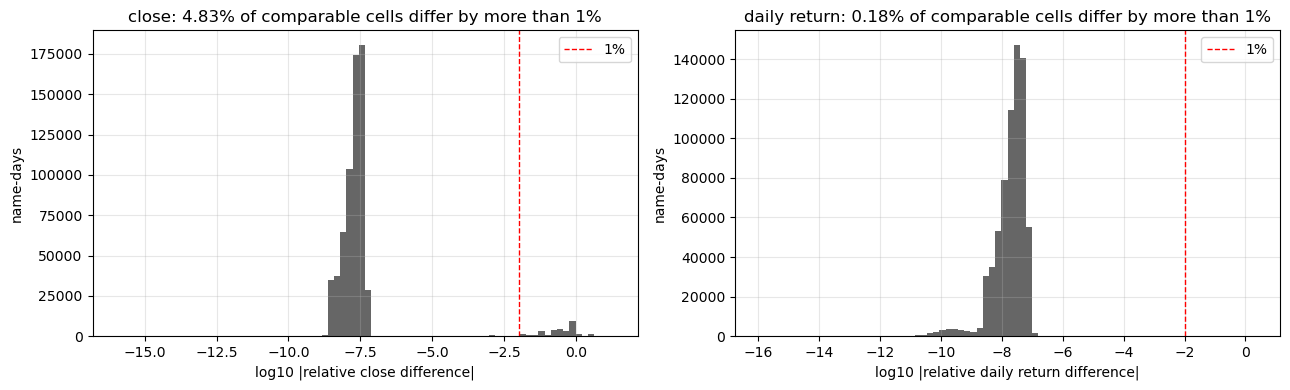

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for a, dat, lab in ((ax[0], rel_px, "close"), (ax[1], rel_ret, "daily return")):
    v = dat.to_numpy().ravel(); v = v[np.isfinite(v) & (v > 0)]
    a.hist(np.log10(v), bins=80, color="0.4")
    a.axvline(np.log10(1e-2), color="r", ls="--", lw=1, label="1%")
    a.set_xlabel(f"log10 |relative {lab} difference|"); a.set_ylabel("name-days"); a.legend()
    a.set_title(f"{lab}: {np.mean(v > 1e-2):.2%} of comparable cells differ by more than 1%")
plt.tight_layout(); plt.show()

The distribution is **bimodal**, and that is the whole story in one picture. The two sources are either
identical to floating-point precision — the median difference is around $10^{-8}$, which is the round-trip
error of storing the same number twice — or they are wildly apart. There is almost nothing in between.

That rules out the explanations one reaches for first. It is not rounding, not a stale bar, not a
different close convention, not a timezone slip. Those would produce a smooth hump of small errors. A
bimodal split means a *discrete* cause: for most names the two feeds carry the same numbers, and for a
minority they carry numbers that differ by a factor.

Note also how much better **returns** agree than **prices**. That is the clue to the mechanism.

## 3. Why: an adjusted price is a function of when you downloaded it

In [5]:
ratio = (yc / lc).where(both)
const = {}
for t in common:
    r = ratio[t].dropna()
    if len(r) < 100:
        continue
    if abs(r.median() - 1) > 0.01 and r.std() < 1e-3:      # off by a factor, and the factor is CONSTANT
        const[t] = float(r.median())

print(f"{len(const)} of {len(common)} tickers differ by a constant factor on every single session:\n")
cs = pd.Series(const).sort_values()
display(cs.to_frame("yahoo / lake").round(4))

15 of 505 tickers differ by a constant factor on every single session:



,yahoo / lake
BKNG,0.0400
NFLX,0.1000
KLAC,0.1000
NOW,0.2000
CRWD,0.2500
TPL,0.3333
APH,0.5000
MNST,0.5000
FDX,0.8058
CMCSA,0.9372


In [6]:
# for each of them, ask the lake what it thinks the raw (unadjusted) price was
raw = load_daily_bars(list(cs.index), START, END, MARKET, price="raw")["close"].unstack("ticker")
chk = pd.DataFrame({
    "yahoo close":     yc[cs.index].iloc[0],
    "lake split close": lc[cs.index].iloc[0],
    "lake raw close":  raw.loc[grid[0], cs.index],
    "yahoo / lake":    cs,
})
chk["lake split applied?"] = (chk["lake split close"] - chk["lake raw close"]).abs() > 1e-6
display(chk.round(4))

# can the cached data explain the factor? only if Yahoo recorded the action itself
rows = []
for t in cs.index:
    sr = yah.xs(t, level="ticker").get("split_ratio")
    ev = sr[sr.notna() & sr.ne(1.0) & sr.ne(0.0)] if sr is not None else pd.Series(dtype=float)
    after = [float(v) for d, v in ev.items() if str(d.date()) > END]
    prod  = float(np.prod(after)) if after else np.nan
    rows.append({"ticker": t, "yahoo / lake": cs[t], "implied factor": 1 / cs[t],
                 "action recorded after the lake ends": after or None,
                 "matches?": (abs(prod - 1 / cs[t]) < 0.02) if after else False})
expl = pd.DataFrame(rows).set_index("ticker")
display(expl.round(4))
print(f"\nexactly explained by an action visible in the cached window: "
      f"{int(expl['matches?'].sum())} of {len(expl)}")

,yahoo close,lake split close,lake raw close,yahoo / lake,lake split applied?
BKNG,82.9832,2074.5800,2074.58,0.0400,False
NFLX,32.9810,329.8100,329.81,0.1000,False
KLAC,18.2570,182.5700,182.57,0.1000,False
NOW,58.2480,291.2400,291.24,0.2000,False
CRWD,12.3600,49.4400,49.44,0.2500,False
TPL,86.1244,258.3733,775.12,0.3333,True
APH,13.6538,27.3075,109.23,0.5000,True
MNST,15.9250,31.8500,63.70,0.5000,True
FDX,124.9799,155.1000,155.10,0.8058,False
CMCSA,42.5211,45.3700,45.37,0.9372,False


,yahoo / lake,implied factor,action recorded after the lake ends,matches?
ticker,,,,
BKNG,0.0400,25.0000,None,False
NFLX,0.1000,10.0000,[10.0],True
KLAC,0.1000,10.0000,None,False
NOW,0.2000,5.0000,[5.0],True
CRWD,0.2500,4.0000,None,False
TPL,0.3333,3.0000,[3.0],True
APH,0.5000,2.0000,None,False
MNST,0.5000,2.0000,None,False
FDX,0.8058,1.2410,None,False



exactly explained by an action visible in the cached window: 3 of 15


The factors are constant to a standard deviation of order $10^{-8}$ across more than a thousand sessions.
The two feeds are carrying the **same price path**, scaled by a number.

Some of those numbers are the obvious ones — 25, 10, 5, 4, 3, 2 — and some are not: 1.241 on FedEx, 1.067
on Comcast, 1.057 on S&P Global. Round or not, the mechanism is the same. Yahoo's adjusted close is
re-based every time a corporate action lands, so the price it reports for January 2020 *today* is not the
price it reported for January 2020 last year. The lake is a snapshot and still carries the older basis.
A whole-number factor is a split; a number like 1.241 is a spinoff, where the parent's history is marked
down by the value of what left.

**But notice how little of this the data can actually prove.** Only three of the names — Netflix, ServiceNow
and Texas Pacific Land — carry an action inside the cached window that exactly accounts for their factor.
For the rest, nothing in either source explains the number: the event happened after the Yahoo cache's own
last date, so it is not in the `split_ratio` column either, even though it has already been baked into
every adjusted close in the file.

That is the sharper version of the lesson. It is not merely that adjusted prices change under you. It is
that **a downloaded adjusted series does not carry the information needed to reconstruct its own basis.**
You can detect that two snapshots disagree, as we just did, but you cannot tell from the files why, or
which of them matches the basis your other data is on.

This is not a bug in either source. It is a property of adjusted series that is easy to forget:

> An adjusted price is not a measurement. It is a measurement *plus every corporate action since*, and it
> changes under you whenever a new one lands.

**The practical consequence** is the asymmetry already visible in §2. A uniform rescaling is invisible in
returns — divide every price by ten and every return is unchanged — which is why returns agree on 99.8% of
name-days. But it is not invisible to anything that reads a **level**: a share count, a notional, a
capital base, a dollar-neutral hedge ratio, a \$5 minimum-price filter. A backtest that computes returns
from one source and position sizes from another is silently wrong, and nothing in the output looks odd.

## 4. Corporate actions that are not just a rescaling

In [7]:
# a constant factor is a split; a factor that changes ONCE is a spinoff; a factor that
# wanders is the two feeds tracking different instruments under one ticker
prefix, wander = {}, {}
for t in common:
    r = ratio[t].dropna()
    if len(r) < 100 or t in const:
        continue
    off = r[(r - 1).abs() > 0.01]
    if len(off) < 20:                       # a handful of odd days is not a corporate action
        continue
    brk = off.index.max()
    pre = r.loc[:brk]
    if abs(pre.median() - 1) < 0.01:        # the prefix must actually sit off 1
        continue
    (prefix if pre.std() < 0.02 else wander)[t] = (brk.date(), float(pre.median()), float(pre.std()))

print(f"{len(prefix)} tickers: one clean break, constant before it  (spinoff / special distribution)")
display(pd.DataFrame(prefix, index=["break", "ratio before", "sd before"]).T.sort_values("break"))
print(f"\n{len(wander)} tickers: the ratio wanders  (the two feeds are not tracking the same instrument)")
display(pd.DataFrame(wander, index=["last disagreement", "median ratio", "sd"]).T)

14 tickers: one clean break, constant before it  (spinoff / special distribution)


,break,ratio before,sd before
IR,2020-02-28,0.264059,0.006143
FTV,2020-10-08,0.83682,0.0
PFE,2020-11-16,0.948767,0.0
MRK,2021-06-02,0.954198,0.0
DTE,2021-06-30,0.851064,0.0
IP,2021-09-30,0.94697,0.0
O,2021-11-12,0.968992,0.0
EXC,2022-02-01,0.713267,0.000013
ZBH,2022-02-28,0.970874,0.0
T,2022-04-08,0.755287,0.0



3 tickers: the ratio wanders  (the two feeds are not tracking the same instrument)


,last disagreement,median ratio,sd
CZR,2020-07-20,3.221323,0.958545
DOC,2024-02-29,1.643035,0.167168
PARA,2025-08-06,6.323957,5.135882


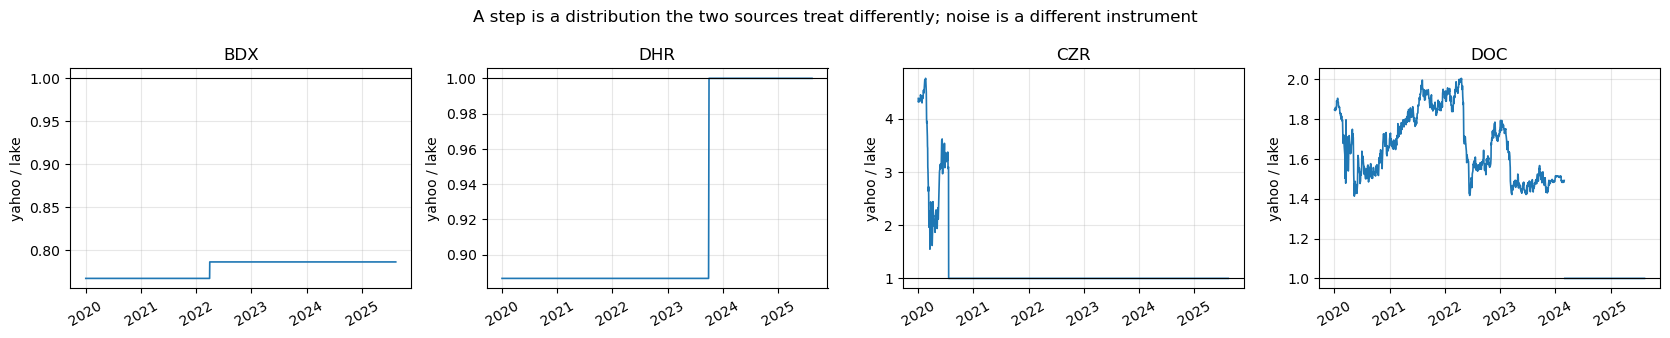

In [8]:
show = list(prefix)[:2] + list(wander)[:2]
fig, axes = plt.subplots(1, len(show), figsize=(4.2 * len(show), 3.4), squeeze=False)
for a, t in zip(axes[0], show):
    a.plot(ratio.index, ratio[t], lw=1.2, color="tab:blue")
    a.axhline(1.0, color="k", lw=0.8)
    a.set_title(t); a.set_ylabel("yahoo / lake")
    a.tick_params(axis="x", rotation=30)
fig.suptitle("A step is a distribution the two sources treat differently; noise is a different instrument")
plt.tight_layout(); plt.show()

Two more mechanisms, and they are different in kind from the rescaling above.

**A single step.** The ratio is one constant before a date and exactly 1.0 after it. That is a **spinoff**:
Yahoo back-adjusts the parent's pre-event history downwards by the value of what was spun off, so the
return series is continuous through the event; the lake's split-only basis leaves the drop in. Here neither
convention is wrong, but they answer different questions — *"what would I have paid?"* against *"what did
this holding earn?"* — and a study that mixes them will read a spinoff as a one-day crash.

**A wandering ratio.** The two feeds are not tracking the same company. A ticker was reassigned, or a
merger moved it to a different instrument. The lake can see this because it resolves each ticker to a FIGI;
Yahoo has only the string, so it silently splices two companies into one price series. This is the trap
notebook 07 measures across the whole market, visible here in a 505-name list that is supposed to be clean.

## 5. Coverage and survivorship

,in today's list,gone by today,share surviving (%)
year,,,
2006,196,304,39.2
2010,217,283,43.4
2014,232,268,46.4
2018,287,213,57.4
2022,284,216,56.8


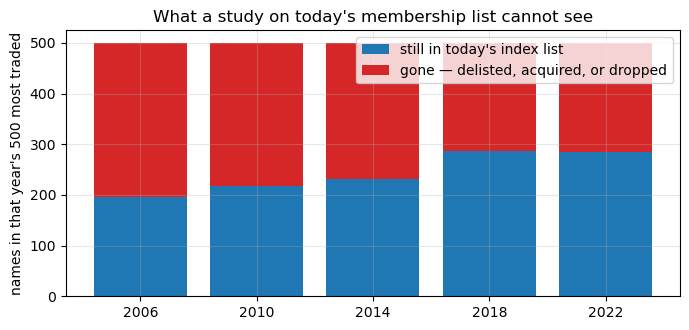

In [9]:
# what the liquid universe actually looked like, year by year, against today's list
today = set(ytk)
rows = []
for yr in (2006, 2010, 2014, 2018, 2022):
    w = load_daily_bars(None, f"{yr}-01-01", f"{yr}-12-31", MARKET, price="split")
    dv = w.groupby(level="ticker")["dollar_volume"].median().sort_values(ascending=False)
    top = set(dv.head(500).index)
    rows.append({"year": yr, "in today's list": len(top & today),
                 "gone by today": len(top - today), "share surviving": len(top & today) / 500})
cov = pd.DataFrame(rows).set_index("year")
display(cov.assign(**{"share surviving": (cov["share surviving"] * 100).round(1)})
           .rename(columns={"share surviving": "share surviving (%)"}))

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.bar(cov.index.astype(str), cov["in today's list"], label="still in today's index list", color="tab:blue")
ax.bar(cov.index.astype(str), cov["gone by today"], bottom=cov["in today's list"],
       label="gone — delisted, acquired, or dropped", color="tab:red")
ax.set_ylabel("names in that year's 500 most traded"); ax.legend()
ax.set_title("What a study on today's membership list cannot see")
plt.tight_layout(); plt.show()

This is the bias notebooks 01–05 carry. The numbers are larger than the phrase "survivorship bias"
suggests: of the 500 most-traded US names in **2006, only 39% are in today's index list** — the other 304
were acquired, taken private, delisted or simply fell out. Even 2018 is only 57%. A screen run on today's
membership is a screen run on the subset that survived, and survival correlates with exactly what a pairs
study is trying to measure: whether a relationship held together.

The lake has all of them, because it is the whole market rather than a list. That, and not data quality,
is the substantive reason to prefer it. Notebook 07 prices the effect on a buy-and-hold portfolio at
**+6.1% a year and +0.28 Sharpe**; notebook 09 finds it is enough to flip the sign of the distance rule.

Note the direction of the coverage result, though: among the **505 names in today's list**, the lake has
every one. Yahoo is not missing data on the names it covers. It is missing the names.

## 6. The four traps, side by side

In [10]:
probe_start, probe_end = "2024-01-01", "2024-12-31"
mkt = load_daily_bars(None, probe_start, probe_end, MARKET, price="split")
mtk = set(mkt.index.get_level_values("ticker").unique())

test_pat = re.compile(r"Z[A-Z]ZZT")
traps = pd.DataFrame(
    [
        ["exchange test symbols",
         sorted(t for t in today if test_pat.fullmatch(t)) or "none",
         sorted(t for t in mtk if test_pat.fullmatch(t))],
        ["ticker reuse (same string, different company)",
         "undetectable — no instrument id",
         f"{len(lake.attrs.get('ticker_collisions', []))} among these 505: "
         f"{[c['ticker'] for c in lake.attrs.get('ticker_collisions', [])]}"],
        ["split-adjustment price trap",
         "adjusted close only — a $5 floor drops pre-split history",
         "raw_close kept alongside, so gates use the tradeable price"],
        ["dividend look-ahead",
         "a dividend column is provided; the adjusted close already embeds it",
         "explicit: price='split' has no dividend, price='tr' does and is flagged"],
    ],
    columns=["trap", "OpenBB / Yahoo", "day lake"],
).set_index("trap")
display(traps)

,OpenBB / Yahoo,day lake
trap,,
exchange test symbols,none,"[ZJZZT, ZVZZT, ZWZZT, ZXZZT]"
"ticker reuse (same string, different company)",undetectable — no instrument id,"3 among these 505: ['COR', 'GEN', 'META']"
split-adjustment price trap,adjusted close only — a $5 floor drops pre-spl...,"raw_close kept alongside, so gates use the tra..."
dividend look-ahead,a dividend column is provided; the adjusted cl...,"explicit: price='split' has no dividend, price..."


The curated feed is *cleaner* on two of these and *blind* on the other two, which is the honest summary.

Yahoo's list contains no exchange test symbols — someone has already filtered them — while the raw lake
carries them and they produce the largest one-day returns in twenty years. Point to the curated feed.

But Yahoo cannot tell you that a ticker changed company, because it has no identifier beyond the string;
and it gives you one adjusted close, so a minimum-price filter silently means *"the adjusted price today"*
rather than *"what it traded at then"*. The lake exposes both problems precisely because it exposes the
raw material. A feed that hides a problem is not the same as a feed that does not have it.

## 7. Does any of it change a result?

In [11]:
from pairs.models.kalman import _kalman_dynamic_hedge
from pairs.strategies.signals import generate_pair_signals
from pairs.strategies.evaluate import evaluate_pair_signals

PAIR = ("BKNG", "MA")          # notebook 03's walk-forward pick; BKNG is one of the rescaled names

def run(px, label):
    d = px.dropna()
    _, _, states, _ = _kalman_dynamic_hedge("P1", "P2", d, q=1e-5, em_iters=5, mode="filter",
                                            return_params=True)
    frame = d.join(states[["alpha", "beta", "resid"]])
    sig = generate_pair_signals(frame, z_method="robust", z_entry=2.0, z_exit=0.5, z_stop=4.0)
    daily, trades, summ = evaluate_pair_signals(frame[["P1", "P2"]], sig, cost_bps=1.0)
    return {"source": label, "bars": summ["bars"], "Sharpe": summ["sharpe"],
            "ann return": summ["ann_return"], "trades": summ["n_trades"],
            "capital base ($)": summ["capital_base"], "net P&L ($)": summ["net_pnl"],
            "median |z|": float(sig["z"].abs().median())}

py = pd.DataFrame({"P1": yc[PAIR[0]], "P2": yc[PAIR[1]]})
pl = pd.DataFrame({"P1": lc[PAIR[0]], "P2": lc[PAIR[1]]})
res = pd.DataFrame([run(py, "OpenBB / Yahoo"), run(pl, "day lake")]).set_index("source")
display(res.round(4))

print(f"\nprice levels differ by {float((yc[PAIR[0]] / lc[PAIR[0]]).median()):.4f}x on {PAIR[0]} "
      f"and {float((yc[PAIR[1]] / lc[PAIR[1]]).median()):.4f}x on {PAIR[1]}")

,bars,Sharpe,ann return,trades,capital base ($),net P&L ($),median |z|
source,,,,,,,
OpenBB / Yahoo,1411,0.5095,0.028,78,10004.9712,1641.2600,0.6753
day lake,1411,0.7038,0.049,69,10003.4940,2822.4035,0.6718



price levels differ by 0.0400x on BKNG and 1.0000x on MA


I expected this table to show almost nothing, and it does not.

Same pair, same rule, same window, same code — and the Sharpe differs by about **0.19** (0.51 against 0.70),
with 78 trades instead of 69. The difference is not noise in the data: BKNG's *returns* agree between the
two sources to within $3\times10^{-4}$, and MA's to $10^{-7}$. It comes from the price **level**, through
two routes that are easy to miss.

**The Kalman hedge is not scale-invariant.** `q=1e-5` and `r=1.0` are absolute variances, not relative
ones. Dividing BKNG by 25 does not change the spread's shape, but it divides the residual's variance by
625 while leaving `q` and `r` where they were — so the filter's effective signal-to-noise, and therefore
how fast it lets the hedge ratio move, depends on what the prices happen to be denominated in. Measured
here, the residual standard deviation as a fraction of the price is 0.0032 on the Yahoo basis against
0.0024 on the lake's: a third more relative noise, purely from the scaling.

**Rounding is not free either.** A price stored to the cent carries about $10^{-4}$ of relative precision
at \$83 and about $5\times10^{-6}$ at \$2,075. Rescaling a series downward and storing it to two decimals
throws away significant figures, which is exactly why BKNG's returns differ at the fourth decimal while
MA's — unscaled — agree at the seventh.

So the answer to "does the data source matter?" is not the comfortable one. **The ratio is robust to the
adjustment basis only if your model is.** Any hyperparameter with units — a variance, a minimum price, a
notional, an impact ADV — silently couples your result to the snapshot you happened to download. The fix
is not to pick the "right" source; it is to make the model scale-free, and to keep raw prices and
adjustment factors separately so the basis can be reconstructed.

## 8. Honest assessment

**The two sources agree far better than the switch to the lake implies.** On returns — which is what every
Sharpe in this repository is computed from — they match to eight decimal places on 99.8% of name-days, and
every exception is a corporate action rather than an error. Nothing in notebooks 01–05 is wrong *because*
it used Yahoo.

**The reason to prefer the lake is coverage, not accuracy.** Today's membership list cannot show you the
names that did not make it, and the shortfall is large: only 39% of 2006's five hundred most-traded names
are still on the list, and only 57% of 2018's. That is a bias in the question being asked, and no amount
of data quality fixes it.

**Adjusted prices are not stable objects.** The largest disagreements here are not errors at all — they are
the same price path on two different adjustment bases, because a split landed between one download and the
other. Any analysis pinned to price *levels* inherits the download date. Cache the raw series and the
adjustment factors separately, as the lake does, and the problem goes away; cache an adjusted close, as
the Yahoo path does, and it does not.

**What the curated feed buys you is a filter, and what it costs you is visibility.** No test symbols, no
obvious junk — but also no instrument identity, no raw price, and no way to know a ticker changed hands.
Notebook 07 can find those problems only because the lake does not hide them.

**Caveats.** One universe and one six-year window; the Yahoo side is a cached snapshot rather than a live
pull, so its adjustment basis is itself frozen at the download date and a fresh download would move the
constants in §3 again — which is the point. The spinoff and reassignment classification in §4 is
mechanical, based on the shape of the ratio, and is a hypothesis about each name rather than a
corporate-actions lookup.